Accompanies Section `subsec:kernel_anal_case` (Analytic solution for $\kappa=0$ and $I=90$) of the paper: the edge-on closed form of Eq. `eq:kernel_edgeon_closed`, extended to all harmonics.

# Closed-form kernel for $I=90°$, $\kappa=0$, uniform $p(\Phi)$

For solid-body rotation ($\kappa=0$) the cosines factor out of the latitude integral of the full kernel (Eq. `eq:kernel_full`), and the kernel is Eq. `eq:kernel_n2` with $N$ harmonics:

$$\mathcal{K}(\tau) = \sigma_k^2\, R_\Gamma(\tau) \left[ \langle |c_0|^2 \rangle_\Phi + 2\sum_{n=1}^N \langle |c_n|^2 \rangle_\Phi \cos(n\omega_0 \tau) \right], \qquad \omega_0 = 2\pi/P_{\rm eq},$$

with amplitude $\sigma_k^2 = \dot N_{\rm spot}(1-f_{\rm spot})^2\alpha_{\max}^4$ (Eq. `eq:sigma_k_cspot`). The spot latitude is $\Phi \in [-\pi/2, \pi/2]$ with uniform $p(\Phi) = 1/\pi$, and $\langle |c_n|^2 \rangle_\Phi = \int_{-\pi/2}^{\pi/2} |c_n(\Phi)|^2 \, p(\Phi)\, d\Phi$.

For $I = \pi/2$:
- $b_0 = \cos I \sin\Phi = 0$
- $b_1 = \sin I \cos\Phi = \cos\Phi \ge 0$ at every latitude
- $\theta_{\rm vis} = \arccos(-b_0/b_1) = \pi/2$ for every $\Phi$: each spot is visible for half a rotation, in either hemisphere (no latitude is hidden, since the hidden cap $\Phi \le -I$ is empty at $I = \pi/2$)

The paper's equations are taken from the equation registry `src/derivations/equations.py`.

## Setup: $c_n$ expressions for $I = \pi/2$

From Appendix `app:fourier_visibility` of the paper (Eq. `eq:cn_general`), the Fourier coefficients of the visibility function $\mathcal{V}(t) = \max\{\cos\beta(t), 0\}$ are:

$$c_n = \frac{1}{\pi}\left[b_0 \frac{\sin(n\,\theta_{\rm vis})}{n} + \frac{b_1}{2}\left(\frac{\sin((n-1)\theta_{\rm vis})}{n-1} + \frac{\sin((n+1)\theta_{\rm vis})}{n+1}\right)\right]$$

with $c_0 = \frac{1}{\pi}(b_0\,\theta_{\rm vis} + b_1 \sin\theta_{\rm vis})$ and $c_{\pm1} = \frac{1}{\pi}\left(b_0\sin\theta_{\rm vis} + \frac{b_1}{2}(\theta_{\rm vis} + \sin\theta_{\rm vis}\cos\theta_{\rm vis})\right)$.

For $I = \pi/2$: $b_0 = 0$, $b_1 = \cos\Phi$, $\theta_{\rm vis} = \pi/2$.

In [1]:
import sys
from pathlib import Path
from IPython.display import display, Math
import sympy as sp
from sympy import pi, cos, sin, sqrt, Rational, integrate, simplify, trigsimp, symbols, oo, latex

# The paper's equations, transcribed once into SymPy (src/derivations/equations.py)
sys.path.insert(0, str(Path.cwd().parent / "src" / "derivations"))
import equations as eqs

In [2]:
Phi = sp.Symbol('Phi', real=True)   # spot latitude, Phi in [-pi/2, pi/2] (the registry's symbol)
n = sp.Symbol('n', integer=True, positive=True)

# For I = pi/2:  b0 = 0,  b1 = cos(Phi) >= 0,  theta_vis = pi/2
b0 = sp.Integer(0)
b1 = cos(Phi)
theta_vis = pi / 2

In [3]:
# c_0 = (1/pi) * (b0*theta_vis + b1*sin(theta_vis))
c0 = (b0 * theta_vis + b1 * sin(theta_vis)) / pi
display(c0)

# c_1 = (1/pi) * (b0*sin(theta_vis) + b1/2 * (theta_vis + sin(theta_vis)*cos(theta_vis)))
c1 = (b0 * sin(theta_vis) + b1/2 * (theta_vis + sin(theta_vis) * cos(theta_vis))) / pi
display(c1)

cos(Phi)/pi

cos(Phi)/4

In [4]:
# General c_n for n >= 2, with b0=0, theta_vis=pi/2
# c_n = (1/pi) * [b0*sin(n*theta_vis)/n + b1/2*(sin((n-1)*theta_vis)/(n-1) + sin((n+1)*theta_vis)/(n+1))]
# With b0=0, theta_vis=pi/2:
# c_n = (cos(Phi)/(2*pi)) * [sin((n-1)*pi/2)/(n-1) + sin((n+1)*pi/2)/(n+1)]

def cn_explicit(n_val):
    """Compute c_n for specific integer n at I=90, theta_vis=pi/2."""
    if n_val == 0:
        return cos(Phi) / pi
    elif n_val == 1:
        return cos(Phi) / (2*pi) * (pi/2)  # simplify c1
    else:
        term1 = sin((n_val - 1) * pi / 2) / (n_val - 1)
        term2 = sin((n_val + 1) * pi / 2) / (n_val + 1)
        return cos(Phi) / (2 * pi) * (term1 + term2)

# Compute c_n for n = 0, 1, 2, 3, 4, 5 and check them against Eq. cn_edgeon
cn_edgeon_paper = eqs.get("eq:cn_edgeon").expr
print("Explicit c_n at I=90°, theta_vis=pi/2:")
print("=" * 40)
cn_values = {}
for nn in range(6):
    cn = simplify(cn_explicit(nn))
    assert simplify(cn - cn_edgeon_paper.subs(eqs.n, nn)) == 0
    cn_values[nn] = cn
    display(Math(f"  c_{nn} = {latex(cn)}"))
print("Verified: equal to Eq. cn_edgeon for n = 0, ..., 5")

Explicit c_n at I=90°, theta_vis=pi/2:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Verified: equal to Eq. cn_edgeon for n = 0, ..., 5


## Key observation

At $I=90°$, all $c_n$ are proportional to $\cos\Phi$ (Eq. `eq:cn_edgeon`):

$$c_n(\Phi) = g_n \cos\Phi$$

where $g_n$ is a constant (independent of $\Phi$). Therefore:

$$|c_n(\Phi)|^2 = g_n^2 \cos^2\Phi$$

The latitude average over the paper's range $\Phi \in [-\pi/2, \pi/2]$ with $p(\Phi) = 1/\pi$ becomes:

$$\langle |c_n|^2 \rangle_\Phi = \frac{1}{\pi}\int_{-\pi/2}^{\pi/2} g_n^2 \cos^2\Phi \, d\Phi = \frac{g_n^2}{\pi} \cdot \frac{\pi}{2} = \frac{g_n^2}{2}$$

(Every latitude contributes: at $I=90°$, $b_1 = \cos\Phi \ge 0$ on the whole range, so spots in both hemispheres are visible for half a rotation.)

Let's verify this with sympy and compute the exact $g_n^2/2$ values.

In [5]:
# Compute <|c_n|^2>_Phi = (1/pi) * integral_{-pi/2}^{pi/2} |c_n(Phi)|^2 dPhi

print("Latitude-averaged |c_n|^2 at I=90°, uniform p(Φ) = 1/π on [-π/2, π/2]:")
print("=" * 60)

cn_sq_avg = {}
for nn in range(6):
    cn = cn_values[nn]
    result_simplified = simplify(integrate(cn**2, (Phi, -pi/2, pi/2)) / pi)
    gn = simplify(cn / cos(Phi))
    assert simplify(result_simplified - gn**2 / 2) == 0     # = g_n^2 / 2
    cn_sq_avg[nn] = result_simplified
    display(Math(rf"  \langle|c_{nn}|^2\rangle_\Phi = {latex(result_simplified)}"))

Latitude-averaged |c_n|^2 at I=90°, uniform p(Φ) = 1/π on [-π/2, π/2]:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Full closed-form kernel

Now assemble the full kernel. For $I=90°$, $\kappa=0$, uniform $p(\Phi)$ on $[-\pi/2, \pi/2]$:

$$\mathcal{K}(\tau) = \sigma_k^2 \, R_\Gamma(\tau) \left[\langle|c_0|^2\rangle_\Phi + 2\sum_{n=1}^N \langle|c_n|^2\rangle_\Phi \cos(n\omega_0\tau)\right], \qquad \sigma_k^2 = \dot N_{\rm spot}(1-f_{\rm spot})^2\alpha_{\max}^4,$$

where each $\langle|c_n|^2\rangle_\Phi$ is a known constant. Let's write the closed form; truncated at $N = 2$ it must be Eq. `eq:kernel_edgeon_closed`.

In [6]:
# Paper symbols: lag tau, rotation frequency omega_0, amplitude sigma_k, envelope ACF R_Gamma
tau, omega0, sigma_k, R_Gamma = eqs.tau, eqs.omega0, eqs.sigma_k, eqs.R_Gamma

# Build the cosine sum with computed coefficients
N_harmonics = 5
cosine_sum = cn_sq_avg[0]
for nn in range(1, N_harmonics + 1):
    cosine_sum += 2 * cn_sq_avg[nn] * cos(nn * omega0 * tau)

cosine_sum_simplified = simplify(cosine_sum)

print("Cosine sum (inside brackets):")
display(Math(f"  {latex(cosine_sum_simplified)}"))
print()

# Factor out 1/pi^2 to see structure more clearly
print("Cosine sum * pi^2:")
display(Math(f"  {latex(simplify(cosine_sum_simplified * pi**2))}"))

# Truncated at n <= 2 it is Eq. kernel_edgeon_closed
K_n2 = sigma_k**2 * R_Gamma(tau) * (cn_sq_avg[0] + 2 * cn_sq_avg[1] * cos(omega0 * tau)
                                    + 2 * cn_sq_avg[2] * cos(2 * omega0 * tau))
assert simplify(K_n2 - eqs.get("eq:kernel_edgeon_closed").expr) == 0
print("\nVerified: truncated at n <= 2, the kernel is Eq. kernel_edgeon_closed")

Cosine sum (inside brackets):


<IPython.core.display.Math object>


Cosine sum * pi^2:


<IPython.core.display.Math object>


Verified: truncated at n <= 2, the kernel is Eq. kernel_edgeon_closed


In [7]:
# Find a general closed-form pattern for <|c_n|^2>_Phi
# We know c_n = cos(Phi) * g_n where g_n is a constant
# So <|c_n|^2>_Phi = g_n^2 * (1/pi) * integral_{-pi/2}^{pi/2} cos^2(Phi) dPhi = g_n^2 / 2

# Let's compute g_n for many n and look for a pattern
print("g_n values (c_n = cos(Phi) * g_n):")
print("=" * 50)
gn_values = {}
for nn in range(10):
    cn = cn_values.get(nn, cn_explicit(nn))
    # Factor out cos(Phi)
    gn = simplify(cn / cos(Phi))
    gn_values[nn] = gn
    display(Math(rf"  n={nn}:\quad g_{nn} = {latex(gn)},\quad g_{nn}^2/2 = {latex(simplify(gn**2 / 2))}"))

g_n values (c_n = cos(Phi) * g_n):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Check for general $n$ pattern

For $b_0 = 0$, $\theta_{\rm vis} = \pi/2$, the general formula gives:

$$g_n = \frac{1}{2\pi}\left[\frac{\sin((n-1)\pi/2)}{n-1} + \frac{\sin((n+1)\pi/2)}{n+1}\right]$$

Note that $\sin(m\pi/2) = 0$ for even $m$, and $\pm 1$ for odd $m$. So:
- For **even** $n$: both $n-1$ and $n+1$ are odd → nonzero
- For **odd** $n \geq 3$: both $n-1$ and $n+1$ are even → $g_n = 0$

This means only $c_0$, $c_1$, and even harmonics ($c_2, c_4, \ldots$) contribute!

In [8]:
# Derive closed-form g_n for even n >= 2
# sin((n-1)*pi/2) for even n: n-1 is odd, sin(odd*pi/2) = (-1)^((odd-1)/2)
# sin((n+1)*pi/2) for even n: n+1 is odd, sin(odd*pi/2) = (-1)^((odd-1)/2)

m = sp.Symbol('m', integer=True, positive=True)  # n = 2m

# For n = 2m:
# sin((2m-1)*pi/2) = (-1)^(m-1)
# sin((2m+1)*pi/2) = (-1)^m

# g_{2m} = (1/(2*pi)) * [(-1)^(m-1)/(2m-1) + (-1)^m/(2m+1)]
#        = (1/(2*pi)) * (-1)^(m-1) * [1/(2m-1) - 1/(2m+1)]
#        = (1/(2*pi)) * (-1)^(m-1) * 2/((2m-1)(2m+1))
#        = (-1)^(m-1) / (pi * (2m-1)*(2m+1))
#        = (-1)^(m-1) / (pi * (4m^2 - 1))

g_2m = (-1)**(m-1) / (pi * (4*m**2 - 1))
display(Math(f"  g_{{2m}} = {latex(g_2m)}"))
print()

# <|c_{2m}|^2>_Phi = g_{2m}^2 / 2 = 1 / (2 * pi^2 * (4m^2-1)^2)
cn_sq_2m = g_2m**2 / 2
cn_sq_2m_simplified = simplify(cn_sq_2m)
display(Math(rf"  \langle|c_{{2m}}|^2\rangle_\Phi = {latex(cn_sq_2m_simplified)}"))
print()

# Verify against the latitude integral of the explicit c_n
print("Verification:")
for mm in range(1, 6):
    nn = 2 * mm
    expected = simplify(cn_sq_2m.subs(m, mm))
    computed = simplify(integrate(cn_explicit(nn)**2, (Phi, -pi/2, pi/2)) / pi)
    match = simplify(expected - computed) == 0
    display(Math(rf"  n={nn}\ (m={mm}):\ \text{{formula}}={latex(expected)},\ "
                 rf"\text{{latitude integral}}={latex(computed)},\ \text{{match}}={match}"))
    assert match

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Verification:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
# Now assemble the full closed-form kernel expression
# K(tau) = sigma_k^2 * R_Gamma(tau) * S(tau)
# where S(tau) = <|c_0|^2> + 2*<|c_1|^2>*cos(w0*tau) + 2*sum_{m=1}^inf <|c_{2m}|^2>*cos(2m*w0*tau)
#
# g_0 = 1/pi, g_1 = 1/4, and <|c_n|^2>_Phi = g_n^2/2:
# <|c_0|^2> = 1/(2*pi^2)
# <|c_1|^2> = 1/32

g0_val = sp.Rational(1, 1) / pi  # = 1/pi
g1_val = sp.Rational(1, 4)       # = 1/4

c0_sq_avg = simplify(g0_val**2 / 2)
c1_sq_avg = simplify(g1_val**2 / 2)
assert c0_sq_avg == cn_sq_avg[0] and c1_sq_avg == cn_sq_avg[1]

print(f"<|c_0|^2> = {c0_sq_avg}")
print(f"<|c_1|^2> = {c1_sq_avg}")
print()

# Write the full kernel
print("CLOSED-FORM KERNEL for I=90°, kappa=0, uniform p(Phi) on [-pi/2, pi/2]:")
print("=" * 60)
print()
print("K(tau) = sigma_k^2 * R_Gamma(tau) * [")
print(f"    {c0_sq_avg}  (n=0 term)")
print(f"  + 2 * {c1_sq_avg} * cos(omega_0 * tau)  (n=1 term)")
print(f"  + 2 * sum_{{m=1}}^inf  1/(2*pi^2*(4m^2-1)^2) * cos(2m*omega_0*tau)  (even harmonics)")
print("]")
print()

# Check if the infinite sum converges to something nice
# sum_{m=1}^inf 1/(4m^2-1)^2 = (pi^2 - 8) / 16  (known series)
print("Known series: sum_{m=1}^inf 1/(4m^2-1)^2 = (pi^2 - 8)/16")
print()

# Verify numerically
import math
partial_sum = sum(1/(4*mm**2 - 1)**2 for mm in range(1, 10000))
exact = (math.pi**2 - 8) / 16
print(f"  Partial sum (10000 terms): {partial_sum:.10f}")
print(f"  (pi^2 - 8)/16:            {exact:.10f}")
print(f"  Match: {abs(partial_sum - exact) < 1e-6}")
assert abs(partial_sum - exact) < 1e-6

# Zero-lag check (Parseval): the bracket at tau = 0 is the time- and latitude-averaged V(t)^2.
# For one spot, (1/2pi) int V^2 dtheta = cos^2(Phi) (1/2pi) int_{-pi/2}^{pi/2} cos^2 = cos^2(Phi)/4,
# and the latitude average of cos^2(Phi) is 1/2, so the bracket at tau = 0 is 1/8.
bracket_0 = c0_sq_avg + 2 * c1_sq_avg + 2 * (pi**2 - 8) / (16 * 2 * pi**2)
print(f"\nBracket at tau = 0 (all harmonics): {simplify(bracket_0)}   (expected 1/8)")
assert simplify(bracket_0 - Rational(1, 8)) == 0

<|c_0|^2> = 1/(2*pi**2)
<|c_1|^2> = 1/32

CLOSED-FORM KERNEL for I=90°, kappa=0, uniform p(Phi) on [-pi/2, pi/2]:

K(tau) = sigma_k^2 * R_Gamma(tau) * [
    1/(2*pi**2)  (n=0 term)
  + 2 * 1/32 * cos(omega_0 * tau)  (n=1 term)
  + 2 * sum_{m=1}^inf  1/(2*pi^2*(4m^2-1)^2) * cos(2m*omega_0*tau)  (even harmonics)
]

Known series: sum_{m=1}^inf 1/(4m^2-1)^2 = (pi^2 - 8)/16

  Partial sum (10000 terms): 0.1168502751
  (pi^2 - 8)/16:            0.1168502751
  Match: True

Bracket at tau = 0 (all harmonics): 1/8   (expected 1/8)


In [10]:
# Try sympy to evaluate the tau-dependent sum in closed form
# S(tau) = <|c_0|^2> + 2*<|c_1|^2>*cos(w*tau) + (2/(4*pi^2)) * sum_{m=1}^inf cos(2m*w*tau)/(4m^2-1)^2

# The key sum is: sum_{m=1}^inf cos(2m*x) / (4m^2-1)^2
# Let's see if sympy can evaluate it

x = sp.Symbol('x', real=True)

# Try direct summation
S = sp.summation(cos(2*m*x) / (4*m**2 - 1)**2, (m, 1, oo))
S_simplified = simplify(S)
display(Math(f"  \\sum_{{m=1}}^\\infty \\frac{{\\cos(2 m x)}}{{(4 m^2 - 1)^2}} = {latex(S_simplified)}"))
display(S_simplified)

<IPython.core.display.Math object>

Sum(cos(2*m*x)/(16*m**4 - 8*m**2 + 1), (m, 1, oo))

In [11]:
# If sympy can't evaluate it directly, try partial fractions approach
# 1/(4m^2-1)^2 = 1/((2m-1)(2m+1))^2
# Use partial fraction: 1/(4m^2-1) = (1/2)*(1/(2m-1) - 1/(2m+1))
# So 1/(4m^2-1)^2 = (1/4)*(1/(2m-1) - 1/(2m+1))^2

# Alternative: try the sum with partial fractions
# 1/(4m^2-1)^2 can be decomposed as:
# A/(2m-1) + B/(2m-1)^2 + C/(2m+1) + D/(2m+1)^2

a, b, c, d = sp.symbols('a b c d')
pf = sp.apart(1/(4*m**2-1)**2, m)
print("Partial fraction decomposition:")
print(pf)
print()

# Try a different approach: use known Fourier series
# The function f(x) = (pi/2 - |x|)^2 / 4 for |x| < pi has the Fourier expansion involving 1/n^2 terms
# But our sum has 1/(4m^2-1)^2 which is different

# Let's try to use the identity:
# sum_{m=1}^inf cos(2mx)/(4m^2-1)^2 via partial fractions
# 1/(4m^2-1)^2 = (1/4) * [1/(2m-1)^2 + 1/(2m+1)^2 - 2/((2m-1)(2m+1))]
# ... this gets complicated. Let's just check if sympy gives a result

# Try with finite upper limit and see the pattern
for N in [3, 5, 10]:
    S_N = sp.summation(cos(2*m*x) / (4*m**2 - 1)**2, (m, 1, N))
    print(f"Partial sum (N={N}): {simplify(S_N)}")
    print()

Partial fraction decomposition:
1/(4*(2*m + 1)) + 1/(4*(2*m + 1)**2) - 1/(4*(2*m - 1)) + 1/(4*(2*m - 1)**2)



Partial sum (N=3): cos(2*x)/9 + cos(4*x)/225 + cos(6*x)/1225



Partial sum (N=5): cos(2*x)/9 + cos(4*x)/225 + cos(6*x)/1225 + cos(8*x)/3969 + cos(10*x)/9801



Partial sum (N=10): cos(2*x)/9 + cos(4*x)/225 + cos(6*x)/1225 + cos(8*x)/3969 + cos(10*x)/9801 + cos(12*x)/20449 + cos(14*x)/38025 + cos(16*x)/65025 + cos(18*x)/104329 + cos(20*x)/159201



In [12]:
# Partial fractions: 1/(4m^2-1)^2 = (1/4) [1/(2m-1)^2 - 2/((2m-1)(2m+1)) + 1/(2m+1)^2], so
#   S(x) = sum_{m>=1} cos(2mx)/(4m^2-1)^2 = (S1 - 2*S2 + S3)/4,  with
#   S1 = sum cos(2mx)/(2m-1)^2,   S2 = sum cos(2mx)/((2m-1)(2m+1)),   S3 = sum cos(2mx)/(2m+1)^2.
#
# S2 is elementary (the Fourier series of |sin x|):  S2 = 1/2 - (pi/4)|sin x|.
# S1 and S3 are not, separately: with k = 2m -/+ 1 (odd), cos(2mx) = cos(kx)cos(x) -/+ sin(kx)sin(x),
# so each contains the Clausen-type sum D(x) = sum_{k odd} sin(kx)/k^2, which has no elementary form.
# But D cancels in S1 + S3, leaving only C(x) = sum_{k odd} cos(kx)/k^2 = (pi/8)(pi - 2|x|):
#   S1 = cos(x) C - sin(x) D,   S3 = cos(x) (C - cos x) + sin(x) (D - sin x)
#   S1 + S3 = 2 cos(x) C(x) - 1 = (pi/4)(pi - 2|x|) cos(x) - 1,      |x| <= pi.
# Hence S(x) = (pi/16)(pi - 2|x|) cos(x) + (pi/8)|sin x| - 1/2  for |x| <= pi.

import numpy as np

m_arr = np.arange(1, 200001)
x_test = 0.7
S1_num = np.sum(np.cos(2*m_arr*x_test) / (2*m_arr - 1)**2)
S2_num = np.sum(np.cos(2*m_arr*x_test) / ((2*m_arr - 1)*(2*m_arr + 1)))
S3_num = np.sum(np.cos(2*m_arr*x_test) / (2*m_arr + 1)**2)

S2_exact = 0.5 - np.pi/4 * abs(np.sin(x_test))
S13_exact = np.pi/4 * (np.pi - 2*abs(x_test)) * np.cos(x_test) - 1

print(f"At x = {x_test}:")
print(f"  S1 (numerical)      = {S1_num:.8f}")
print(f"  S2 (numerical)      = {S2_num:.8f}")
print(f"  S2 (exact)          = {S2_exact:.8f}")
print(f"  S3 (numerical)      = {S3_num:.8f}")
print(f"  S1 + S3 (numerical) = {S1_num + S3_num:.8f}")
print(f"  S1 + S3 (exact)     = {S13_exact:.8f}   [(pi/4)(pi - 2|x|) cos x - 1]")
assert abs(S2_num - S2_exact) < 1e-8
assert abs(S1_num + S3_num - S13_exact) < 1e-8

S_exact_test = np.pi/16 * (np.pi - 2*abs(x_test)) * np.cos(x_test) + np.pi/8 * abs(np.sin(x_test)) - 0.5
print(f"\n  S = (S1 - 2 S2 + S3)/4 (numerical) = {(S1_num - 2*S2_num + S3_num)/4:.10f}")
print(f"  S closed form                      = {S_exact_test:.10f}")
assert abs((S1_num - 2*S2_num + S3_num)/4 - S_exact_test) < 1e-8

At x = 0.7:
  S1 (numerical)      = 0.06402914
  S2 (numerical)      = -0.00596739
  S2 (exact)          = -0.00596739
  S3 (numerical)      = -0.01784459
  S1 + S3 (numerical) = 0.04618455
  S1 + S3 (exact)     = 0.04618455   [(pi/4)(pi - 2|x|) cos x - 1]

  S = (S1 - 2 S2 + S3)/4 (numerical) = 0.0145298306
  S closed form                      = 0.0145298306


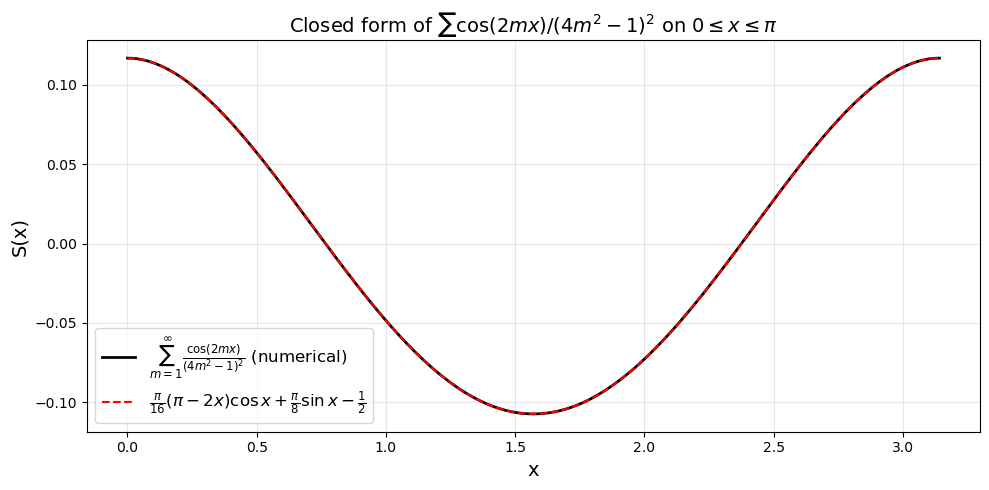

S(0)    = 0.11685028   [(pi^2-8)/16 = 0.11685028]
S(pi/2) = -0.10730092   [pi/8 - 1/2  = -0.10730092]
S(pi)   = 0.11685028


In [13]:
# Check the closed form of the full sum S(x) = sum_{m=1}^inf cos(2mx)/(4m^2-1)^2 on [0, pi]

x_vals = np.linspace(0, np.pi, 201)
S_numerical = np.zeros_like(x_vals)
for mm in range(1, 5000):
    S_numerical += np.cos(2*mm*x_vals) / (4*mm**2 - 1)**2

# Closed form for 0 <= x <= pi (S is even and pi-periodic)
S_closed_np = np.pi/16 * (np.pi - 2*x_vals) * np.cos(x_vals) + np.pi/8 * np.sin(x_vals) - 0.5
assert np.max(np.abs(S_numerical - S_closed_np)) < 1e-10

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_vals, S_numerical, 'k-', lw=2, label=r'$\sum_{m=1}^\infty \frac{\cos(2mx)}{(4m^2-1)^2}$ (numerical)')
ax.plot(x_vals, S_closed_np, 'r--', lw=1.5,
        label=r'$\frac{\pi}{16}(\pi - 2x)\cos x + \frac{\pi}{8}\sin x - \frac{1}{2}$')
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('S(x)', fontsize=14)
ax.legend(fontsize=12)
ax.set_title(r'Closed form of $\sum \cos(2mx)/(4m^2-1)^2$ on $0 \leq x \leq \pi$', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print values at key points
print(f"S(0)    = {S_numerical[0]:.8f}   [(pi^2-8)/16 = {(np.pi**2-8)/16:.8f}]")
print(f"S(pi/2) = {S_numerical[100]:.8f}   [pi/8 - 1/2  = {np.pi/8 - 0.5:.8f}]")
print(f"S(pi)   = {S_numerical[-1]:.8f}")

## Closed form of the full harmonic sum

The partial-fraction route shows that the $\tau$-dependent sum is elementary after all: the Clausen-type pieces cancel. A direct way to see it is Parseval's theorem for Fourier series. The $g_n$ are the Fourier coefficients of the half-rectified cosine $h(\theta) = \max\{\cos\theta, 0\}$, so $\sum_n g_n^2 e^{inx}$ is its circular autocorrelation:
$$\sum_{n=-\infty}^{\infty} g_n^2\, e^{inx} = \frac{1}{2\pi}\int_{-\pi}^{\pi} h(\theta)\,h(\theta + x)\,d\theta .$$
For $0 \le x \le \pi$ the two visible windows overlap on $[-\pi/2,\, \pi/2 - x]$, which leaves one elementary integral. With $\langle|c_n|^2\rangle_\Phi = g_n^2/2$, the bracket of the all-harmonic kernel is half of it, evaluated at $x = \omega_0\tau$ folded into $[0, \pi]$.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

max |exact - (n <= 2)| = 5.81e-04  = 0.47% of the zero-lag value 1/8
max |exact - (n <= 4)| = 1.31e-04  = 0.10% of the zero-lag value 1/8


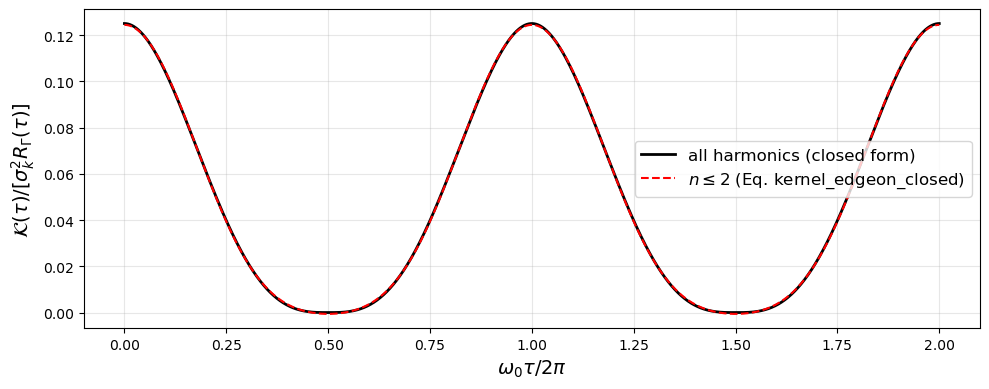

In [14]:
theta = sp.Symbol('theta', real=True)

# Circular autocorrelation of h(theta) = max(cos(theta), 0), for 0 <= x <= pi
C_h = simplify(integrate(cos(theta) * cos(theta + x), (theta, -pi/2, pi/2 - x)) / (2*pi))
display(Math(rf"\frac{{1}}{{2\pi}}\int_{{-\pi}}^{{\pi}} h(\theta)\,h(\theta+x)\,d\theta = {latex(C_h)}"
             rf"\qquad (0 \le x \le \pi)"))

# Its Fourier series is g_0^2 + 2 g_1^2 cos(x) + 2 sum_m g_{2m}^2 cos(2mx)
#                     = 1/pi^2 + cos(x)/8 + (2/pi^2) S(x), so
S_closed = sp.expand((C_h - 1/pi**2 - cos(x)/8) * pi**2 / 2)
display(Math(rf"\sum_{{m=1}}^\infty \frac{{\cos(2mx)}}{{(4m^2-1)^2}} = {latex(S_closed)}\qquad (0 \le x \le \pi)"))
assert simplify(S_closed - (pi/16*(pi - 2*x)*cos(x) + pi/8*sin(x) - Rational(1, 2))) == 0   # = partial fractions
assert simplify(S_closed.subs(x, 0) - (pi**2 - 8)/16) == 0

# The all-harmonic bracket: sum_n <|c_n|^2>_Phi cos(n x) = C_h(x) / 2
bracket_all = simplify(C_h / 2)
display(Math(rf"\mathcal{{K}}(\tau) = \sigma_k^2 R_\Gamma(\tau)\,{latex(bracket_all)},"
             rf"\qquad x = \arccos\big(\cos(\omega_0\tau)\big) \in [0, \pi]"))
assert simplify(bracket_all.subs(x, 0) - Rational(1, 8)) == 0

# Numerical check against the series, over two rotation periods
xg = np.linspace(0, 4*np.pi, 2001)       # omega_0 * tau
x_fold = np.arccos(np.cos(xg))            # fold into [0, pi]: cos(x_fold) = cos(xg), sin(x_fold) = |sin(xg)|
bracket_fn = sp.lambdify(x, bracket_all, "numpy")
bracket_exact = bracket_fn(x_fold)
bracket_series = (1/(2*np.pi**2) + np.cos(xg)/16
                  + sum(np.cos(2*mm*xg) / (np.pi**2 * (4*mm**2 - 1)**2) for mm in range(1, 2001)))
assert np.max(np.abs(bracket_exact - bracket_series)) < 1e-10

# How much does the n <= 2 truncation (Eq. kernel_edgeon_closed) miss?
bracket_n2 = 1/(2*np.pi**2) + np.cos(xg)/16 + np.cos(2*xg)/(9*np.pi**2)
bracket_n4 = bracket_n2 + np.cos(4*xg)/(225*np.pi**2)
for label, br in [("n <= 2", bracket_n2), ("n <= 4", bracket_n4)]:
    err = np.max(np.abs(bracket_exact - br))
    print(f"max |exact - ({label})| = {err:.2e}  = {err / (1/8):.2%} of the zero-lag value 1/8")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xg / (2*np.pi), bracket_exact, 'k-', lw=2, label='all harmonics (closed form)')
ax.plot(xg / (2*np.pi), bracket_n2, 'r--', lw=1.5, label=r'$n \leq 2$ (Eq. kernel_edgeon_closed)')
ax.set_xlabel(r'$\omega_0\tau / 2\pi$', fontsize=14)
ax.set_ylabel(r'$\mathcal{K}(\tau) / [\sigma_k^2 R_\Gamma(\tau)]$', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

For the special case $I = 90°$, $\kappa = 0$, uniform $p(\Phi) = 1/\pi$ on $[-\pi/2, \pi/2]$:

### What simplifies:
1. **All $c_n$ are proportional to $\cos\Phi$**: $c_n(\Phi) = g_n \cos\Phi$ (Eq. `eq:cn_edgeon`)
2. **Odd harmonics $n \geq 3$ vanish**: only $n = 0, 1, 2, 4, 6, \ldots$ contribute
3. **Latitude integral has a closed form** for each $n$: $\langle|c_n|^2\rangle_\Phi = g_n^2/2$
4. **General formula for even harmonics**: $\langle|c_{2m}|^2\rangle_\Phi = \frac{1}{2\pi^2(4m^2-1)^2}$
5. **The infinite cosine sum is elementary too.** The partial-fraction pieces of $\sum_{m=1}^\infty \frac{\cos(2m\omega_0\tau)}{(4m^2-1)^2}$ contain Clausen-type sums, but these cancel; the whole series is the circular autocorrelation of the half-rectified cosine. The all-harmonic kernel is
$$\mathcal{K}(\tau) = \sigma_k^2 R_\Gamma(\tau)\,\frac{(\pi - x)\cos x + \sin x}{8\pi}, \qquad x = \arccos\big(\cos(\omega_0\tau)\big) \in [0, \pi],$$
with $\mathcal{K}(0) = \sigma_k^2 R_\Gamma(0)/8$.

### Truncated forms
The series converges rapidly ($\sim 1/m^4$). Truncating at $n \le 2$ gives Eq. `eq:kernel_edgeon_closed`, and adding $n = 4$:

$$\mathcal{K}(\tau) \approx \sigma_k^2 R_\Gamma(\tau)\left[\frac{1}{2\pi^2} + \frac{1}{16}\cos(\omega_0\tau) + \frac{1}{9\pi^2}\cos(2\omega_0\tau) + \frac{1}{225\pi^2}\cos(4\omega_0\tau)\right]$$

The $n \le 2$ bracket differs from the exact one by at most $5.8\times10^{-4}$ (at $\tau = 0$; 0.47% of its zero-lag value $1/8$), and the $n \le 4$ bracket by at most $1.3\times10^{-4}$ (0.10%).